In [7]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path.cwd().parent

raw_path = BASE_DIR / "data" / "raw"
processed_path = BASE_DIR / "data" / "processed"

print(raw_path)
print(processed_path)

c:\Users\ASUS\OneDrive\Desktop\bluestock-mf-capstone\data\raw
c:\Users\ASUS\OneDrive\Desktop\bluestock-mf-capstone\data\processed


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

processed_path = Path("../data/processed")

nav = pd.read_csv(processed_path/"02_nav_history_clean.csv")
performance = pd.read_csv(processed_path/"clean_performance.csv")
transactions = pd.read_csv(processed_path/"clean_transactions.csv")
fund_master = pd.read_csv(processed_path/"clean_fund_master.csv")

In [11]:
print(nav.shape)
print(performance.shape)
print(transactions.shape)
print(fund_master.shape)

(46000, 3)
(40, 19)
(32778, 13)
(40, 15)


In [12]:
nav['date'] = pd.to_datetime(nav['date'])
transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

In [13]:
nav = nav.sort_values(['amfi_code', 'date'])

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
    .pct_change()
)

In [15]:
from pathlib import Path

Path("../reports").mkdir(parents=True, exist_ok=True)

var_cvar.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

In [16]:
results = []

for fund, group in nav.groupby('amfi_code'):
    returns = group['daily_return'].dropna()

    if len(returns) > 0:
        var95 = np.percentile(returns, 5)
        cvar95 = returns[returns <= var95].mean()

        results.append({
            'amfi_code': fund,
            'VaR_95': var95,
            'CVaR_95': cvar95
        })

var_cvar = pd.DataFrame(results)
var_cvar.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

var_cvar.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


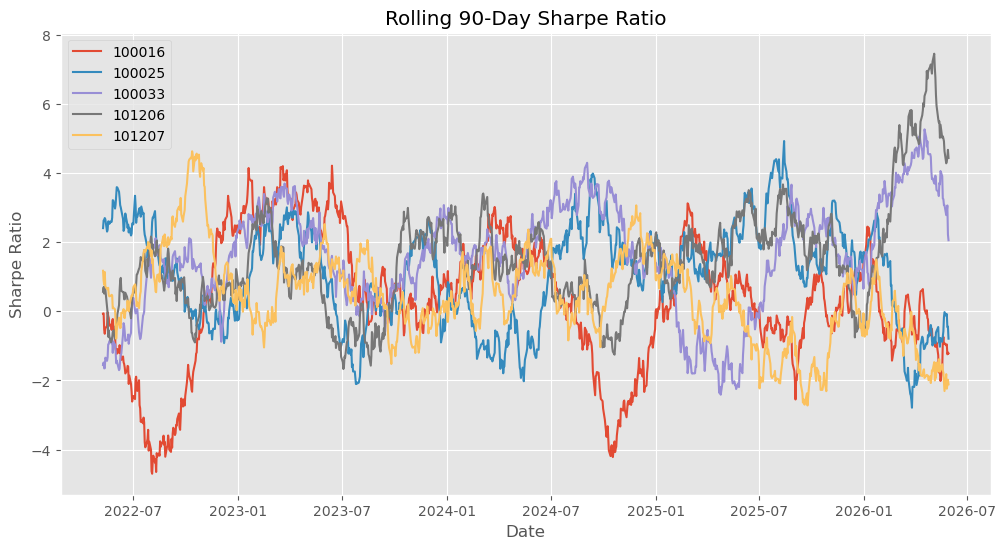

In [17]:
sample_funds = nav['amfi_code'].unique()[:5]

plt.figure(figsize=(12,6))

for fund in sample_funds:
    temp = nav[nav['amfi_code'] == fund].copy()

    rolling_mean = temp['daily_return'].rolling(90).mean()
    rolling_std = temp['daily_return'].rolling(90).std()

    sharpe = (rolling_mean / rolling_std) * np.sqrt(252)

    plt.plot(temp['date'], sharpe, label=str(fund))

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
transactions['first_year'] = (
    transactions.groupby('investor_id')
    ['transaction_date']
    .transform('min')
    .dt.year
)

cohort = transactions.groupby(
    'first_year'
).agg(
    avg_sip_amount=('amount_inr', 'mean'),
    total_invested=('amount_inr', 'sum'),
    total_transactions=('investor_id', 'count')
).reset_index()

cohort.to_csv(
    "../reports/cohort_analysis.csv",
    index=False
)

cohort

,first_year,avg_sip_amount,total_invested,total_transactions
0,2024,107422.541832,3491125187,32499
1,2025,109158.577061,30455243,279


In [19]:
sip = transactions[
    transactions['transaction_type'] == "SIP"
].copy()

sip = sip.sort_values(
    ['investor_id', 'transaction_date']
)

sip['gap_days'] = sip.groupby(
    'investor_id'
)['transaction_date'].diff().dt.days

sip_analysis = sip.groupby(
    'investor_id'
).agg(
    avg_gap=('gap_days', 'mean'),
    sip_count=('gap_days', 'count')
).reset_index()

sip_analysis = sip_analysis[
    sip_analysis['sip_count'] >= 6
]

sip_analysis['status'] = np.where(
    sip_analysis['avg_gap'] > 35,
    'At Risk',
    'Regular'
)

sip_analysis.to_csv(
    "../reports/sip_continuity.csv",
    index=False
)

sip_analysis.head()

,investor_id,avg_gap,sip_count,status


In [20]:
import pandas as pd

performance = pd.read_csv(
    "../data/processed/clean_performance.csv"
)

def recommend_funds(risk_level):
    filtered = performance[
        performance['risk_grade'] == risk_level
    ]

    top3 = filtered.sort_values(
        by='sharpe_ratio',
        ascending=False
    ).head(3)

    return top3[
        ['scheme_name',
         'risk_grade',
         'sharpe_ratio']
    ]

print(recommend_funds("High"))

                                      scheme_name risk_grade  sharpe_ratio
21  Kotak Emerging Equity Fund - Regular - Growth       High          0.96
12       ICICI Pru Midcap Fund - Regular - Growth       High          0.95
38             DSP Midcap Fund - Regular - Growth       High          0.90


## Key Insights

1. Funds with higher Sharpe Ratios provide better risk-adjusted returns.
2. Historical VaR and CVaR help identify funds with higher downside risk.
3. Recent investor cohorts contribute a significant share of total investments.
4. Investors with SIP gaps greater than 35 days can be classified as at-risk.
5. The fund recommendation engine suggests the top 3 funds based on risk grade and Sharpe Ratio.